# Script for the forthcoming article on Probability and Monte Carlo Simulations

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Vignettes

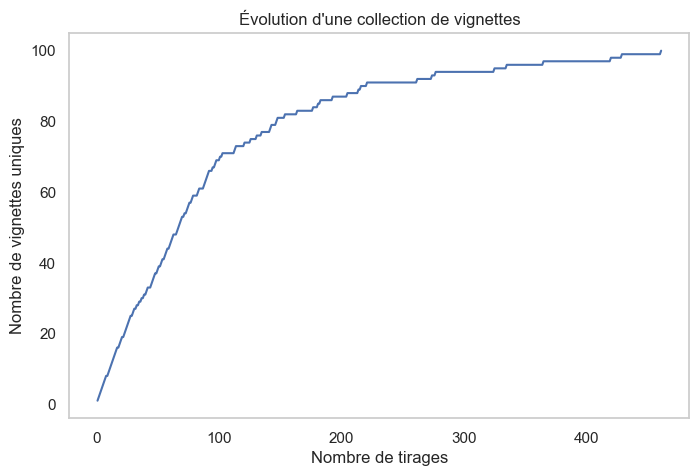

In [49]:
#ici un code fait par chat gpt que je vais essayer de comprendre
#Vs Code and Git test for stuff

import random
import matplotlib.pyplot as plt

def evolution_collection(n):
    collection = set()
    tirages = 0
    
    x_tirages = []
    y_uniques = []

    while len(collection) < n:
        vignette = random.randint(1, n)
        collection.add(vignette)
        tirages += 1

        x_tirages.append(tirages)
        y_uniques.append(len(collection))

    return x_tirages, y_uniques


# nombre total de vignettes
n = 100

x, y = evolution_collection(n)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.xlabel("Nombre de tirages")
plt.ylabel("Nombre de vignettes uniques")
plt.title("Évolution d'une collection de vignettes")
plt.grid()

plt.show()

## Berksons Paradox

Text(0, 0.5, 'Character')

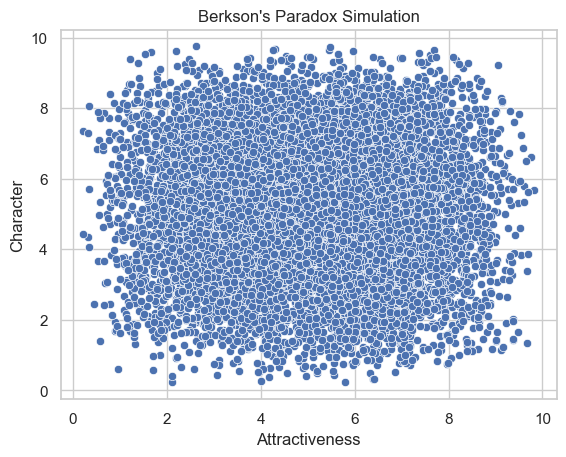

In [50]:
# Set Paramenters

n = 10000
alpha = 3
beta = 3

# Simulate Data
attractiveness = np.random.beta(alpha, beta, n)
attractiveness = attractiveness * 10

character = np.random.beta(alpha, beta, n)
character = character * 10

# Create DataFrame
berksons_df = pd.DataFrame({
    'attractiveness': attractiveness,
    'character': character
})

# Plot the Data
sns.scatterplot(data=berksons_df, x='attractiveness', y='character')
plt.title("Berkson's Paradox Simulation")
plt.xlabel("Attractiveness")
plt.ylabel("Character")


In [51]:
# Regress character on attractiveness to show that there is no correlation
import statsmodels.api as sm

# Add intercept
X_with_const = sm.add_constant(berksons_df[['attractiveness']])

# determine dependent variable (doesnt matter here)
y = berksons_df['character']

# fit OLS
sm_model = sm.OLS(y, X_with_const).fit()

# 3. Print the results (includes Coeff, P-values, and 95% Conf. Intervals)
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2592
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.611
Time:                        16:04:58   Log-Likelihood:                -20516.
No. Observations:               10000   AIC:                         4.104e+04
Df Residuals:                    9998   BIC:                         4.105e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.0842      0.054     94.

In [52]:
# Add a selection bias where the sum of attractiveness and character is >14
berksons_df["bias"] = (berksons_df['attractiveness'] + berksons_df['character']) > 14

In [53]:
selected_group = berksons_df[berksons_df["bias"] == True]

X = sm.add_constant(selected_group['attractiveness'])
y = selected_group['character']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     563.9
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           5.47e-93
Time:                        16:04:58   Log-Likelihood:                -834.85
No. Observations:                 738   AIC:                             1674.
Df Residuals:                     736   BIC:                             1683.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             12.4655      0.209     59.

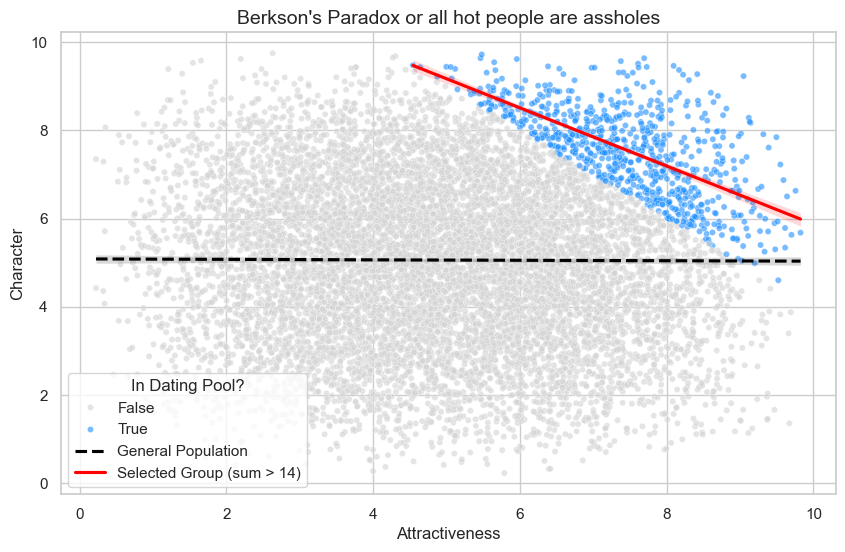

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot  points colored by the bias column
sns.scatterplot(data=berksons_df, x='attractiveness', y='character', 
                hue='bias', palette={True: 'dodgerblue', False: 'lightgray'}, 
                alpha=0.6, s=20)

# Regression Line for full pop
sns.regplot(data=berksons_df, x='attractiveness', y='character', 
            scatter=False, color='black', label='General Population',
            line_kws={"linestyle": "--"})

#Regression Line for selected group
sns.regplot(data=berksons_df[berksons_df['bias'] == True], 
            x='attractiveness', y='character', 
            scatter=False, color='red', label='Selected Group (sum > 14)')

#Formatting
plt.title("Berkson's Paradox or all hot people are assholes", fontsize=14)
plt.xlabel("Attractiveness")
plt.ylabel("Character")
plt.legend(title="In Dating Pool?")
plt.savefig('berksons_paradox.png')
plt.show()

# Winning by loosing

Plots and CSV generated.


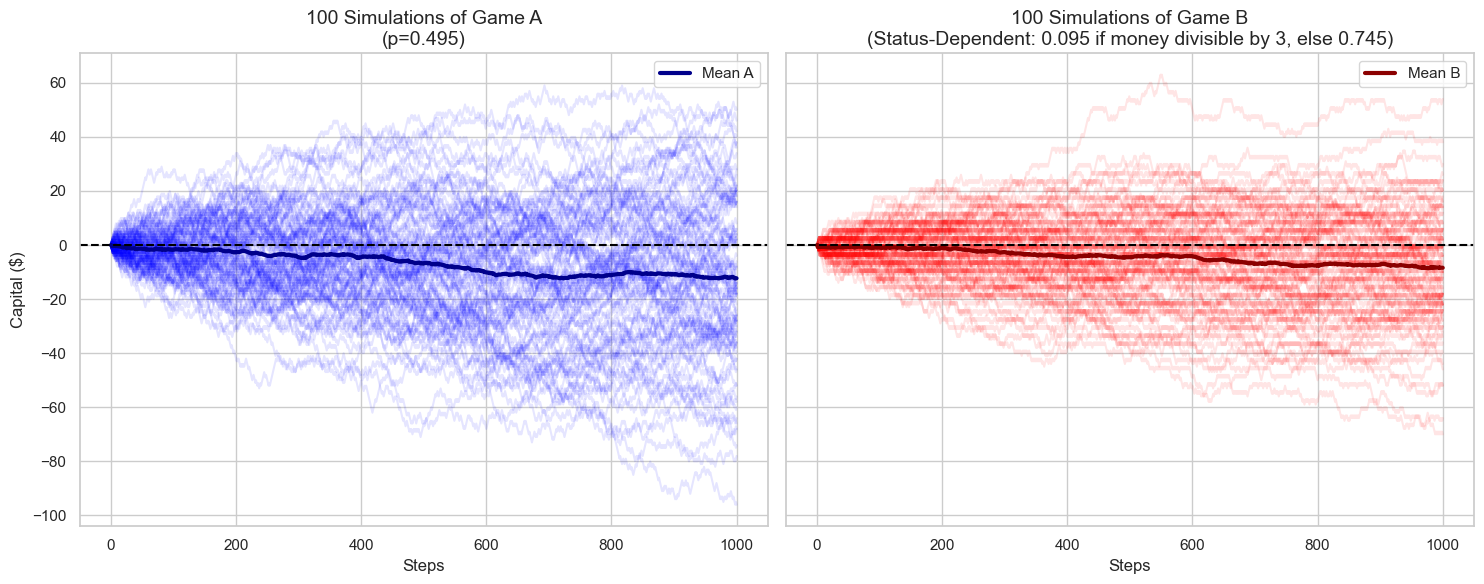

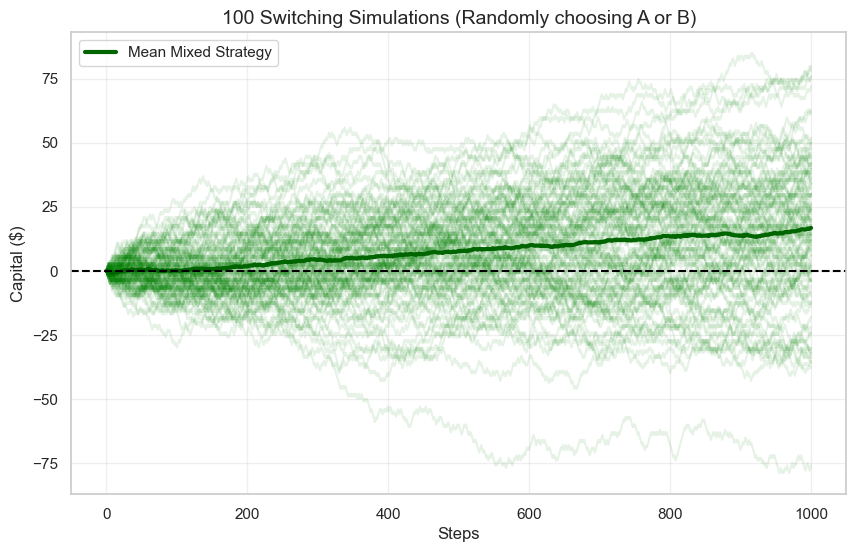

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def play_game_a(current_money):
    return current_money + 1 if np.random.random() < 0.495 else current_money - 1

def play_game_b(current_money):
    p = 0.095 if current_money % 3 == 0 else 0.745
    return current_money + 1 if np.random.random() < p else current_money - 1

def run_simulation(strategy, n_sims=100, n_steps=1000):
    all_paths = np.zeros((n_sims, n_steps + 1))
    for i in range(n_sims):
        money = 0
        for t in range(1, n_steps + 1):
            if strategy == 'A':
                money = play_game_a(money)
            elif strategy == 'B':
                money = play_game_b(money)
            elif strategy == 'Mixed':
                if np.random.random() < 0.5:
                    money = play_game_a(money)
                else:
                    money = play_game_b(money)
            all_paths[i, t] = money
    return all_paths

n_sims = 100
n_steps = 1000

paths_a = run_simulation('A', n_sims, n_steps)
paths_b = run_simulation('B', n_sims, n_steps)
paths_mixed = run_simulation('Mixed', n_sims, n_steps)

# Plot 1: Game A and Game B next to each other
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i in range(n_sims):
    ax1.plot(paths_a[i], color='blue', alpha=0.1)
    ax2.plot(paths_b[i], color='red', alpha=0.1)

ax1.plot(np.mean(paths_a, axis=0), color='darkblue', linewidth=3, label='Mean A')
ax2.plot(np.mean(paths_b, axis=0), color='darkred', linewidth=3, label='Mean B')

ax1.set_title("100 Simulations of Game A\n(p=0.495)", fontsize=14)
ax1.set_xlabel("Steps")
ax1.set_ylabel("Capital ($)")
ax1.axhline(0, color='black', linestyle='--')
ax1.legend()

ax2.set_title("100 Simulations of Game B\n(Status-Dependent: 0.095 if money divisible by 3, else 0.745)", fontsize=14)
ax2.set_xlabel("Steps")
ax2.axhline(0, color='black', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.savefig('parrondo_a_b.png')

# Plot 2: Switching simulations
plt.figure(figsize=(10, 6))
for i in range(n_sims):
    plt.plot(paths_mixed[i], color='green', alpha=0.1)
plt.plot(np.mean(paths_mixed, axis=0), color='darkgreen', linewidth=3, label='Mean Mixed Strategy')
plt.axhline(0, color='black', linestyle='--')
plt.title("100 Switching Simulations (Randomly choosing A or B)", fontsize=14)
plt.xlabel("Steps")
plt.ylabel("Capital ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('parrondo_mixed.png')